# Crop Recommendation System — Reproducible Evaluation

This notebook is intentionally thin. Reusable logic is implemented under `src/`; this notebook calls those modules and visualizes generated evidence. The update includes component-level latency profiling, bootstrap confidence intervals, weak multi-label ground truth, and automated tests.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'src'))

from main import main
from config import LATENCY_THRESHOLD_MS, TOP_K

REPORTS = ROOT / 'reports' / 'tables'
print('Repository root:', ROOT)
print('Top-K:', TOP_K)
print('Latency p95 threshold (ms/query):', LATENCY_THRESHOLD_MS)

Repository root: /mnt/data/crop_repo_work/crop-recommendation-system-main
Top-K: 5
Latency p95 threshold (ms/query): 1.0


## 1. Run the full experiment

Set `RUN_FULL_EXPERIMENT=True` to repeat validation tuning, final fitting, multi-label evaluation, bootstrap, latency profiling, and artifact export. The default is `False` because the repository already contains generated tables.

In [2]:
RUN_FULL_EXPERIMENT = False
if RUN_FULL_EXPERIMENT:
    main()

## 2. Single-label and weak multi-label results

The weak labels retain the observed crop and add at most two alternatives using crop-specific 10th--90th percentile suitability envelopes learned only from train+validation data. They are pseudo labels and must not be interpreted as expert-validated agronomic annotations.

In [3]:
results = pd.read_csv(REPORTS / 'test_metrics_single_and_multilabel.csv')
results

,model,metric,ground_truth,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned,Latency_distance_ms,Latency_ranking_ms,Latency_centroid_distance_ms,Latency_cluster_selection_ms,Latency_candidate_distance_ms
0,Exact KNN,cosine,single_label,0.200000,1.000000,0.973864,1.0,0.980708,1.052273,0.070701,1760.000000,1.000000,NaN,0.046910,0.022661,NaN,NaN,NaN
1,Exact KNN,cosine,weak_multilabel,0.392273,0.960227,0.907765,1.0,0.943071,1.009091,0.059434,1760.000000,1.000000,NaN,0.034730,0.022617,NaN,NaN,NaN
2,Exact KNN,euclidean,single_label,0.200000,1.000000,0.992045,1.0,0.994128,1.015909,0.049397,1760.000000,1.000000,NaN,0.029173,0.020093,NaN,NaN,NaN
3,Exact KNN,euclidean,weak_multilabel,0.395455,0.968182,0.907033,1.0,0.945374,1.004545,0.078302,1760.000000,1.000000,NaN,0.057813,0.020357,NaN,NaN,NaN
4,Exact KNN,manhattan,single_label,0.200000,1.000000,0.992045,1.0,0.994128,1.015909,0.082517,1760.000000,1.000000,NaN,0.012588,0.069809,NaN,NaN,NaN
5,Exact KNN,manhattan,weak_multilabel,0.400909,0.981061,0.920088,1.0,0.955429,1.004545,0.032034,1760.000000,1.000000,NaN,0.013436,0.018471,NaN,NaN,NaN
6,KNN + K-Means++,cosine,single_label,0.200000,1.000000,0.978409,1.0,0.984063,1.043182,0.624958,221.734091,0.125985,3.929545,NaN,0.111584,0.001970,0.087835,0.406228
7,KNN + K-Means++,cosine,weak_multilabel,0.390909,0.956439,0.898321,1.0,0.937779,1.004545,0.645624,221.734091,0.125985,3.929545,NaN,0.113323,0.002138,0.089728,0.425719
8,KNN + K-Means++,euclidean,single_label,0.200000,1.000000,0.990530,1.0,0.992992,1.020455,0.524307,240.477273,0.136635,3.963636,NaN,0.122092,0.001053,0.090630,0.296903
9,KNN + K-Means++,euclidean,weak_multilabel,0.395000,0.967045,0.908737,1.0,0.945676,1.009091,0.441448,240.477273,0.136635,3.963636,NaN,0.105670,0.001805,0.083796,0.236896


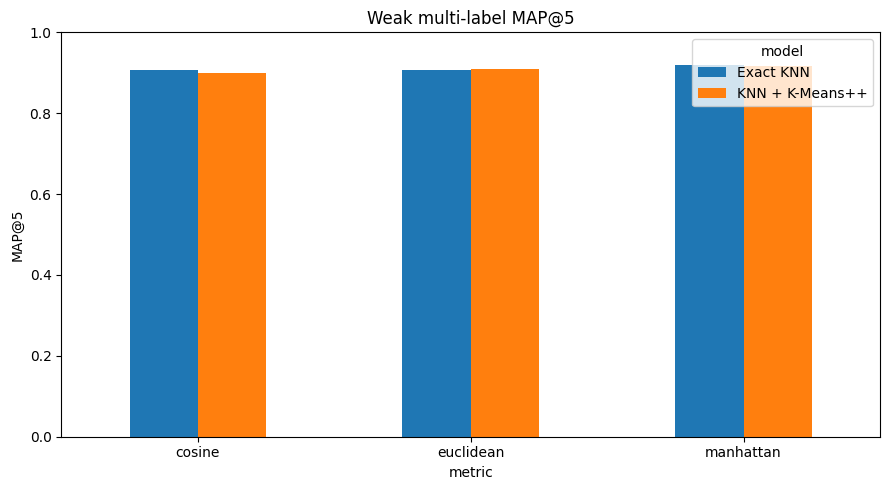

In [4]:
weak = results[results['ground_truth'] == 'weak_multilabel'].copy()
ax = weak.pivot(index='metric', columns='model', values='MAP@K').plot(kind='bar', figsize=(9, 5))
ax.set_ylabel('MAP@5')
ax.set_title('Weak multi-label MAP@5')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Bootstrap confidence intervals and paired model comparison

Each CI uses 2,000 query-level bootstrap resamples. Paired differences are calculated as `hybrid - exact` on the same test queries. A CI containing zero indicates no clear difference at the 95% confidence level.

In [5]:
ci = pd.read_csv(REPORTS / 'bootstrap_confidence_intervals.csv')
ci[ci['ground_truth'] == 'weak_multilabel']

,ground_truth,model,metric,estimate,ci_low,ci_high,confidence,n_resamples
12,weak_multilabel,Exact KNN | cosine,MAP@K,0.907765,0.892651,0.921645,0.95,2000
13,weak_multilabel,Exact KNN | cosine,NDCG@K,0.943071,0.932021,0.953056,0.95,2000
14,weak_multilabel,Exact KNN | euclidean,MAP@K,0.907033,0.892964,0.919949,0.95,2000
15,weak_multilabel,Exact KNN | euclidean,NDCG@K,0.945374,0.935428,0.954289,0.95,2000
16,weak_multilabel,Exact KNN | manhattan,MAP@K,0.920088,0.907765,0.931692,0.95,2000
17,weak_multilabel,Exact KNN | manhattan,NDCG@K,0.955429,0.947247,0.962819,0.95,2000
18,weak_multilabel,KNN + K-Means++ | cosine,MAP@K,0.898321,0.883243,0.912375,0.95,2000
19,weak_multilabel,KNN + K-Means++ | cosine,NDCG@K,0.937779,0.926844,0.947965,0.95,2000
20,weak_multilabel,KNN + K-Means++ | euclidean,MAP@K,0.908737,0.894444,0.922096,0.95,2000
21,weak_multilabel,KNN + K-Means++ | euclidean,NDCG@K,0.945676,0.935641,0.954966,0.95,2000


In [6]:
paired = pd.read_csv(REPORTS / 'paired_bootstrap_model_comparison.csv')
paired[paired['ground_truth'] == 'weak_multilabel']

,ground_truth,distance_metric,metric,difference,estimate,ci_low,ci_high,confidence,n_resamples,conclusion
6,weak_multilabel,euclidean,MAP@K,hybrid_minus_exact,0.001705,-0.004094,0.007502,0.95,2000,no_clear_difference
7,weak_multilabel,euclidean,NDCG@K,hybrid_minus_exact,0.000302,-0.004928,0.005717,0.95,2000,no_clear_difference
8,weak_multilabel,manhattan,MAP@K,hybrid_minus_exact,-0.003725,-0.011039,0.003410,0.95,2000,no_clear_difference
9,weak_multilabel,manhattan,NDCG@K,hybrid_minus_exact,-0.003519,-0.010000,0.002314,0.95,2000,no_clear_difference
10,weak_multilabel,cosine,MAP@K,hybrid_minus_exact,-0.009444,-0.017363,-0.001892,0.95,2000,baseline_better
11,weak_multilabel,cosine,NDCG@K,hybrid_minus_exact,-0.005292,-0.011694,0.000856,0.95,2000,no_clear_difference


## 4. Latency threshold and component analysis

The benchmark uses 100 fixed test queries, three warm-up runs, ten measured runs, and a p95 threshold of 1.0 ms/query. Exact KNN separates distance and ranking time. Hybrid search separates centroid distance, cluster selection, candidate distance, and ranking.

In [7]:
latency = pd.read_csv(REPORTS / 'latency_profile.csv')
latency

,model,metric,workload_queries,warmup_runs,measured_runs,threshold_ms,mean_ms,p50_ms,p95_ms,passes_threshold,component_distance,component_ranking,component_centroid_distance,component_cluster_selection,component_candidate_distance
0,Exact KNN,cosine,100,3,10,1.0,0.059927,0.036852,0.161989,True,0.037469,0.018733,NaN,NaN,NaN
1,Exact KNN,euclidean,100,3,10,1.0,0.032376,0.030278,0.046149,True,0.013235,0.018508,NaN,NaN,NaN
2,Exact KNN,manhattan,100,3,10,1.0,0.030829,0.031141,0.036726,True,0.014005,0.016239,NaN,NaN,NaN
3,KNN + K-Means++,cosine,100,3,10,1.0,0.613893,0.613811,0.666339,True,NaN,0.109015,0.004123,0.086186,0.398133
4,KNN + K-Means++,euclidean,100,3,10,1.0,0.454468,0.454442,0.479704,True,NaN,0.108065,0.003154,0.082546,0.247713
5,KNN + K-Means++,manhattan,100,3,10,1.0,0.490295,0.486080,0.517710,True,NaN,0.153644,0.002644,0.099310,0.219172


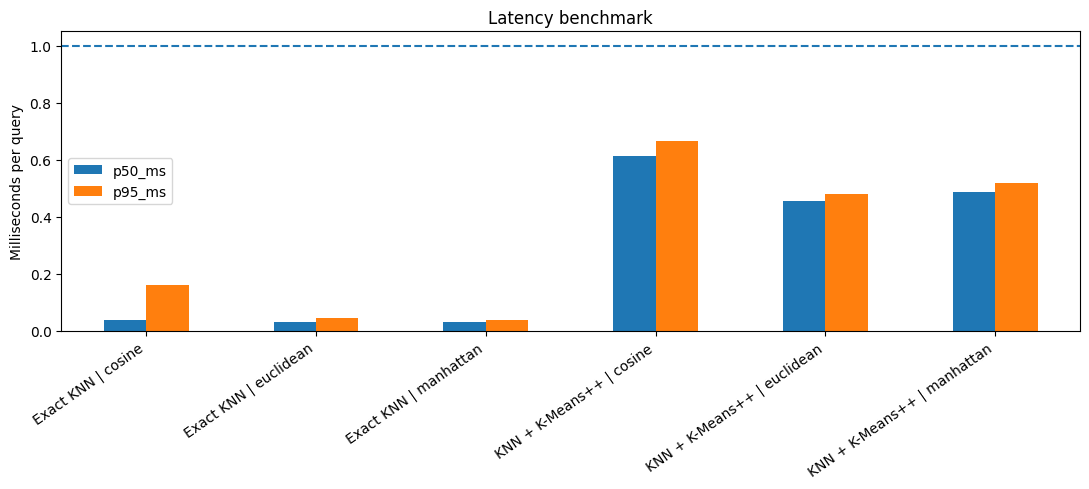

In [8]:
ax = latency.assign(name=latency['model'] + ' | ' + latency['metric']).plot(
    x='name', y=['p50_ms', 'p95_ms'], kind='bar', figsize=(11, 5)
)
ax.axhline(LATENCY_THRESHOLD_MS, linestyle='--', label='threshold')
ax.set_ylabel('Milliseconds per query')
ax.set_xlabel('')
ax.set_title('Latency benchmark')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5. Auditable weak ground truth

In [9]:
weak_labels = pd.read_csv(REPORTS / 'weak_multilabel_ground_truth.csv')
weak_labels.head(15)

,original_label,weak_relevant_crops,relevant_count
0,orange,orange|pomegranate,2
1,banana,banana|watermelon,2
2,cotton,cotton|watermelon,2
3,maize,maize|banana,2
4,orange,orange|pomegranate,2
5,chickpea,chickpea|kidneybeans,2
6,rice,rice|jute,2
7,blackgram,blackgram|lentil|mothbeans,3
8,banana,banana|maize,2
9,orange,orange|pomegranate,2


## 6. Test evidence

Run from the repository root:

```bash
pytest
```

The current repository passes 12 unit/integration tests. Detailed methodology and interpretation are provided in `reports/EXPERIMENT_UPDATE.md`.

## Conclusion

Under weak multi-label evaluation, Exact KNN with Manhattan distance has the highest point estimates. Paired bootstrap results show no clear exact-versus-hybrid difference for Euclidean or Manhattan, while Exact KNN is better for cosine MAP@5. Exact KNN is also faster on this small dataset. The Manhattan hybrid is still a reasonable search-space trade-off because it examines only about one fifth of the train+validation candidates without a clear paired ranking-quality loss.